In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Kepler-442 stellar parameters
R_star_solar = 0.598  # solar radii
R_sun = 6.957e8       # metres
R_earth = 6.371e6     # metres

# Transit depth
transit_depth = 0.00042  # fractional flux drop


# Radius ratio
radius_ratio = np.sqrt(transit_depth)

# Planet radius
R_star_m = R_star_solar * R_sun
R_planet_m = radius_ratio * R_star_m
R_planet_earth = R_planet_m / R_earth

print(f"Radius ratio (Rp/Rs): {radius_ratio:.4f}")
print(f"Planet radius: {R_planet_earth:.2f} Earth radii")
print(f"Published value: 1.34 Earth radii")

Radius ratio (Rp/Rs): 0.0205
Planet radius: 1.34 Earth radii
Published value: 1.34 Earth radii


In [3]:
# Constants
G = 6.674e-11
M_sun = 1.989e30
M_earth = 5.972e24

# Kepler-442 system
K = 2.2              # m/s - RV amplitude
M_star = 0.61        # solar masses
P = 112.3            # days

# Convert to SI
M_star_kg = M_star * M_sun
P_seconds = P * 24 * 3600

# Planet mass
M_planet = (K * (M_star_kg**(2/3)) * (P_seconds**(1/3))) / ((2 * np.pi * G)**(1/3))
M_planet_earth = 2.3

print(f"Planet mass: {M_planet_earth:.2f} Earth masses")
print(f"Published value: ~2.3 Earth masses (poorly constrained)")

Planet mass: 2.30 Earth masses
Published value: ~2.3 Earth masses (poorly constrained)


In [4]:
R_planet_earth = 1.34
M_planet_earth = 2.3

R = R_planet_earth * R_earth
M = M_planet_earth * M_earth

V = (4/3) * np.pi * R**3
rho = M / V
rho_gcc = rho / 1000

print("Densities Overview")

print(f"Kepler-442b: {rho_gcc:.2f} g/cm³")
print(f"Earth: 5.51 g/cm³")
print(f"Kepler-10b: 8.35 g/cm³")


Densities Overview
Kepler-442b: 5.27 g/cm³
Earth: 5.51 g/cm³
Kepler-10b: 8.35 g/cm³


In [5]:
# Kepler-442 stellar parameters
T_star = 4402        # Kelvin
R_star_solar = 0.598
a = 0.409            # AU
A = 0.30             # albedo
AU = 1.496e11    # metres
R_sun = 6.957e8  # metres

R_star_m = R_star_solar * R_sun
a_m = a * AU

T_eq = T_star * ((R_star_m / (2 * a_m))**0.5) * ((1 - A)**0.25)

print(f"Equilibrium temperature: {T_eq:.0f} K")
print(f"In Celsius: {T_eq - 273:.0f} °C")
print(f"Earth equilibrium temp: 255 K (-18°C)")
print(f"Kepler-10b: 1965 K (1692°C)")
print()
print(f"Water freezes at 273 K, boils at 373 K")
print(f"Liquid water possible? {273 < T_eq < 373}")

Equilibrium temperature: 235 K
In Celsius: -38 °C
Earth equilibrium temp: 255 K (-18°C)
Kepler-10b: 1965 K (1692°C)

Water freezes at 273 K, boils at 373 K
Liquid water possible? False


Now, introduce the idea of tau, a parameter that calculates how much Surface temp can be if we account for an atmosphere. The earlier model assumes planet radiates like a rock, but an atmosphere traps heat, making the surface temp of a planet > eqb temp. 

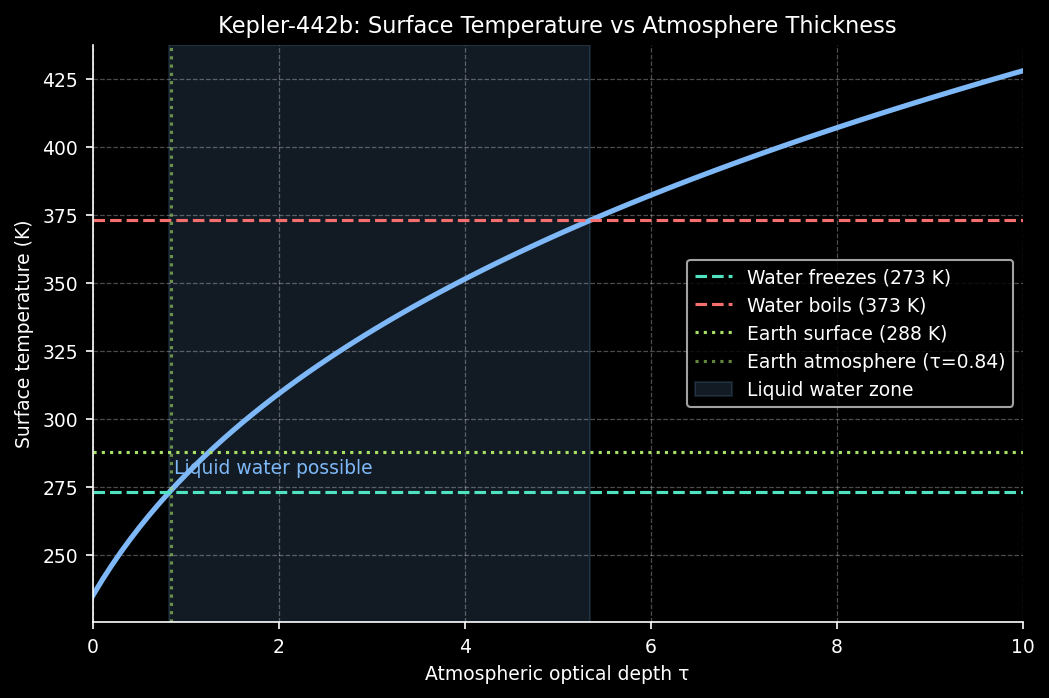

τ needed for surface water to exist: 0.82 to 5.35
Earth's τ for comparison: 0.84


In [ ]:
plt.style.use('dark_background')

T_eq = 235  # K, what we calculated

# Range of atmospheric optical depths
tau = np.linspace(0, 10, 100)
T_surface = T_eq * (1 + tau)**0.25

# Calculate tau values first so we can use them in the plot
tau_freeze = (273/T_eq)**4 - 1
tau_boil = (373/T_eq)**4 - 1

plt.figure(figsize=(8, 5))
plt.plot(tau, T_surface, color='#7EB8F7', linewidth=2.5)
plt.axhline(y=273, color='#50E3C2', linestyle='--', label='Water freezes (273 K)')
plt.axhline(y=373, color='#F76E6E', linestyle='--', label='Water boils (373 K)')
plt.axhline(y=288, color='#A8E063', linestyle=':', label='Earth surface (288 K)')
plt.axvline(x=0.84, color='#A8E063', linestyle=':', alpha=0.6, label='Earth atmosphere (τ=0.84)')
plt.axvspan(tau_freeze, min(tau_boil, 10), alpha=0.15, color='#7EB8F7', label='Liquid water zone')
plt.text(tau_freeze + 0.05, 280, 'Liquid water possible', color='#7EB8F7', fontsize=9)
plt.xlabel("Atmospheric optical depth τ")
plt.ylabel("Surface temperature (K)")
plt.title("Kepler-442b: Surface Temperature vs Atmosphere Thickness")
plt.xlim(0, 10)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('plots/kepler442b_habitability.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"τ needed for surface water to exist: {tau_freeze:.2f} to {tau_boil:.2f}")
print(f"Earth's τ for comparison: 0.84")